# Slow farmer Kolmogorov equations for $N_w$ only

In [171]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

import pickle
import time

In [172]:
#set serif font
plt.rcParams["font.family"]="serif"
plt.rcParams["mathtext.fontset"]="dejavuserif"

In [173]:
#colorblind optimized color cycle
#https://doi.org/10.1038/nmeth.1618
wong_colors = ["#000000", "#E69F00",
               "#56B4e9", "#009E73",
               "#F0E442", "#0072B2",
               "#D55E00", "#CC79A7"]
wong_cycle = mpl.rcsetup.cycler(color=wong_colors)

In [174]:
R = 0.00888
K = 0.00772

## setting up system

In [175]:
def timeToIndex(ar, t):
    """given array of times, ar, returns the largest index i such that ar[i]<t"""

    if ar[-1] < t:
        raise IndexError("Time t is out of bounds of array ar")
        
    i = 0
    while ar[i+1] <= t:
        i += 1
    return i

In [176]:
def pmfE(p):
    """calculate the expected value of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""

    return np.sum(p * np.arange(0, p.size))

def pmfVar(p):
    """calculate the variance of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""
    return np.sum(p*(np.arange(0, p.size)-pmfE(p))**2)

In [177]:
def growthRate(Ng, N, A):
    return K*Ng*(1-Ng/A)

def eatRate(Ng, N, A):
    return N*R*Ng/A

In [178]:
def quasiEqRec(N, A):
    mat = np.zeros((A, A))
    for i in range(1, A):
        #each loop inserts equation p_i+1 mu_i+1 - p_i lambda_i = 0
        mat[i-1, i] = eatRate(i+1, N, A)
        mat[i-1, i-1] = -growthRate(i, N, A)

    #final row for probability=1 equation
    for i in range(0, A):
        mat[-1, i] = 1

    #dependent variable vector
    b = np.zeros(A)
    b[-1]=1

    #concatenate a zero to the beginning to represent p_0=0
    #important for use with pmfE() and pmfVar(), which assume that p_i appears at index i
    return np.concatenate((np.array([0]), np.linalg.solve(mat, b)))

In [179]:
def rMatrix(N, A):

    p = quasiEqRec(N, A)

    #function to allow subscipting p outside of 0 <= x <= A
    def p_x(x):
        if x > A or x < 0:
            return 0
        else:
            return p[x]

    def r_ij(i, j):
        if i == j:
            return np.sum([
                -p_x(x)*growthRate(x, N, A) + p_x(x+1)*eatRate(x+1, N, A)*i/N for x in range(0, A+1)
            ])
        elif i == j-1:
            return np.sum([
                p_x(y+1)*eatRate(y+1, N, A)*(N-j+1)/N for y in range(0, A+1)
            ])
        else:
            return 0

    r_matrix = np.zeros((N+1, N+1))

    for i in range(0, N+1):
        for j in range(0, N+1):
            r_matrix[i,j] = r_ij(i, j)

    return r_matrix

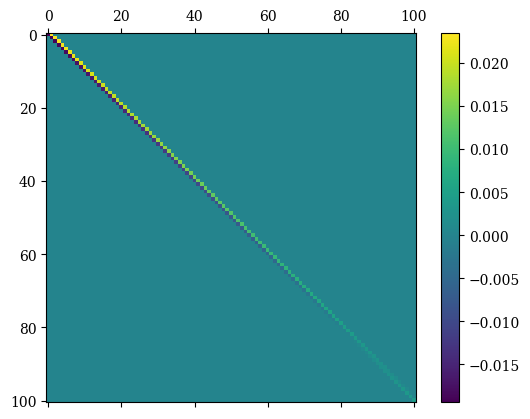

In [180]:
r = rMatrix(100, 100)

f, ax = plt.subplots()

im = ax.matshow(r)

plt.colorbar(im)

In [181]:
def simulate(N, A, stoptime):

    r_matrix = rMatrix(N, A)

    q0 = np.zeros(N+1)
    #begin pasture Nw=0
    #meaning q_0 = 1
    q0[0]=1

    def sys(t, y):
        return np.matmul(y, r_matrix)

    #specify T_list to ensure data at T=1
    t_list = np.concatenate((np.arange(0, 11), np.arange(100, stoptime+1, 100)))
    
    st = time.time()

    s = sp.integrate.solve_ivp(sys, (0, stoptime), q0, t_eval = t_list)
    print("finished in {0} seconds".format(time.time()-st))

    return s

finished in 0.020603179931640625 seconds


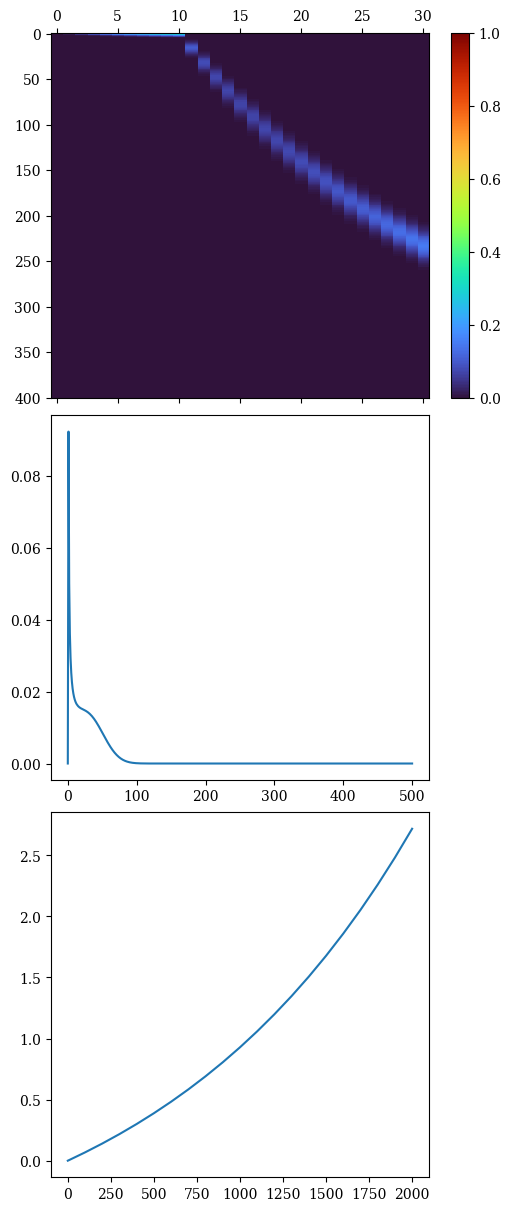

In [182]:
n=400
a=500
b = simulate(n, a, 2000)

f, (ax, ax2, ax3) = plt.subplots(nrows=3, figsize=(5, 12), layout="constrained")
im = ax.matshow(b["y"], cmap="turbo", aspect="auto")

ax2.plot(quasiEqRec(n, a))

ax3.plot(b["t"], np.sum(b["y"], 0)-1)
plt.colorbar(im)

In [183]:
#like for the fast farmer, test values of N from 0.05A up to 0.85A in increments of 0.05A
#test A=60 and 120
#test out to t=1500

sol_100 = {str(i): simulate(i, 100, 1600) for i in range(5, 90, 5)}

sol_200 = {str(i): simulate(i, 200, 1600) for i in range(10, 180, 10)}

sol_500 = {str(i): simulate(i, 500, 1600) for i in range(25, 450, 25)}

finished in 0.0029900074005126953 seconds
finished in 0.003986835479736328 seconds
finished in 0.004108428955078125 seconds
finished in 0.006975412368774414 seconds
finished in 0.007137775421142578 seconds
finished in 0.006114482879638672 seconds
finished in 0.006050825119018555 seconds
finished in 0.006975650787353516 seconds
finished in 0.007012605667114258 seconds
finished in 0.007050514221191406 seconds
finished in 0.006997585296630859 seconds
finished in 0.005979776382446289 seconds
finished in 0.0039844512939453125 seconds
finished in 0.003982067108154297 seconds
finished in 0.0039861202239990234 seconds
finished in 0.0029904842376708984 seconds
finished in 0.001992464065551758 seconds
finished in 0.004986286163330078 seconds
finished in 0.0064389705657958984 seconds
finished in 0.008239507675170898 seconds
finished in 0.008969306945800781 seconds
finished in 0.012956619262695312 seconds
finished in 0.015232563018798828 seconds
finished in 0.013953447341918945 seconds
finished in

## Plot evolution

Text(0.83, 0.9, '(b)')

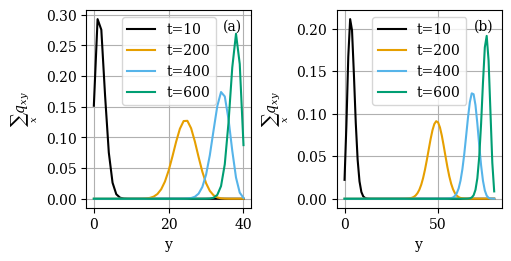

In [184]:
f, (ax1, ax2) = plt.subplots(ncols=2, layout="constrained", figsize=(5, 2.5))

ax1.set_prop_cycle(wong_cycle)
ax2.set_prop_cycle(wong_cycle)

for i in [10, 200, 400, 600]:
    ax2.plot(sol_200["80"]["y"][:,timeToIndex(sol_200["80"]["t"], i)], label="t={0}".format(i))

for i in [10, 200, 400, 600]:
    ax1.plot(sol_100["40"]["y"][:,timeToIndex(sol_100["40"]["t"], i)], label="t={0}".format(i))

ax1.grid(True)
ax1.set_xlabel("y")
ax1.set_ylabel("$\sum_{x}q_{xy}$")
ax1.legend(loc="upper center")

ax2.grid(True)
ax2.set_xlabel("y")
ax2.set_ylabel("$\sum_{x}q_{xy}$")
ax2.legend(loc="upper center")

ax1.annotate("(a)", (0.83, 0.9), xycoords="axes fraction")
ax2.annotate("(b)", (0.83, 0.9), xycoords="axes fraction")

## Plot f_slow

In [191]:
fslow_1_100 = np.array([
    pmfE(sol_100[i]["y"][:,1]) for i in sol_100.keys()
])

fslow_1_500 = np.array([
    pmfE(sol_500[i]["y"][:,1]) for i in sol_500.keys()
])

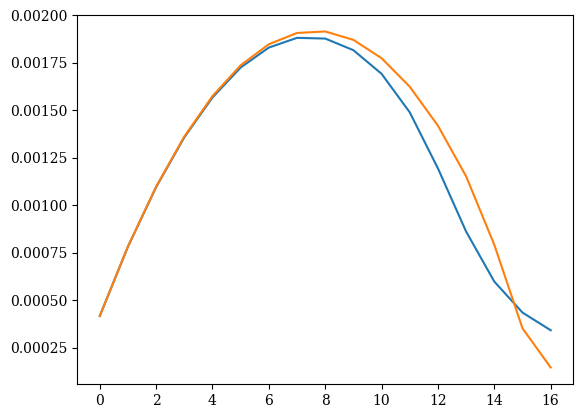

In [192]:
plt.plot(fslow_1_100/100)
plt.plot(fslow_1_500/500)